In [4]:
%reload_ext autoreload
%autoreload 2


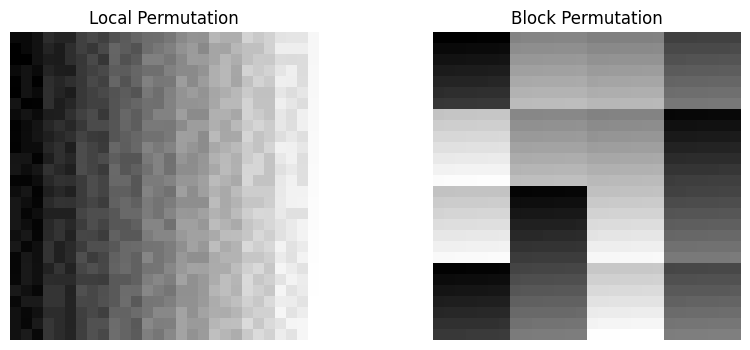

In [5]:
import numpy as np
import matplotlib.pyplot as plt

def local_permutation_indices(height=28, width=28, window=3, orientation='horizontal', seed=None):
    """
    Generate a permutation of flattened indices such that each pixel is only permuted
    within a local window of size `window`x`window` in the 2D image.

    Args:
        height: Height of the image (default 28)
        width: Width of the image (default 28)
        window: Size of the local window (default 3)
        orientation: 'horizontal' or 'vertical' (default 'horizontal')
        seed: Optional random seed

    Returns:
        perm: A permutation of np.arange(height*width) with local shuffling
    """
    rng = np.random.default_rng(seed)
    perm = np.arange(height * width).reshape(height, width)
    out = np.empty_like(perm)
    for i in range(0, height, window):
        for j in range(0, width, window):
            h_end = min(i + window, height)
            w_end = min(j + window, width)
            block = perm[i:h_end, j:w_end].flatten()
            rng.shuffle(block)
            out[i:h_end, j:w_end] = block.reshape(h_end - i, w_end - j)

    if orientation == 'horizontal':
        out = out.T
    else:
        out = out
    return out.flatten()

def block_permutation_indices(height=28, width=28, window=3, seed=None):
    """
    Generate a permutation of flattened indices such that only the order of the blocks
    (of size window x window) is permuted, but the order within each block is preserved.

    Args:
        height: Height of the image (default 28)
        width: Width of the image (default 28)
        window: Size of the block (default 3)
        seed: Optional random seed

    Returns:
        perm: A permutation of np.arange(height*width) with block shuffling
    """
    rng = np.random.default_rng(seed)
    # Compute number of blocks in each dimension
    n_blocks_h = (height + window - 1) // window
    n_blocks_w = (width + window - 1) // window

    # List of all block start indices and their shapes
    block_indices = []
    block_shapes = []
    for i in range(n_blocks_h):
        for j in range(n_blocks_w):
            h_start = i * window
            w_start = j * window
            h_end = min(h_start + window, height)
            w_end = min(w_start + window, width)
            block = np.arange(height * width).reshape(height, width)[h_start:h_end, w_start:w_end].flatten()
            block_indices.append(block)
            block_shapes.append((h_end - h_start, w_end - w_start))

    # Permute the order of the blocks
    perm_order = np.arange(len(block_indices))
    rng.shuffle(perm_order)
    block_indices = [block_indices[i] for i in perm_order]
    block_shapes = [block_shapes[i] for i in perm_order]

    # Reconstruct the permuted array
    perm = np.empty((height, width), dtype=int)
    idx = 0
    for i in range(n_blocks_h):
        for j in range(n_blocks_w):
            h_start = i * window
            w_start = j * window
            h_end = min(h_start + window, height)
            w_end = min(w_start + window, width)
            region_shape = (h_end - h_start, w_end - w_start)
            block = block_indices[idx]
            shape = block_shapes[idx]
            # If the block size does not match the region shape, slice the block accordingly
            expected_size = region_shape[0] * region_shape[1]
            if block.size > expected_size:
                # This happens when the block was originally from a full window but the region is partial (edge)
                block = block[:expected_size]
            elif block.size < expected_size:
                # This should not happen, but just in case, raise an error
                raise ValueError(f"Cannot reshape array of size {block.size} into shape {region_shape}")
            block = block.reshape(region_shape)
            perm[h_start:h_end, w_start:w_end] = block
            idx += 1
    return perm.flatten()

# Example usage:
local_perm = local_permutation_indices(height=28, width=28, window=3, seed=44)
block_perm = block_permutation_indices(height=28, width=28, window=7, seed=44)

plt.figure(figsize=(10,4))
plt.subplot(1,2,1)
plt.title("Local Permutation")
plt.imshow(local_perm.reshape(28,28), cmap='gray')
plt.axis('off')
plt.subplot(1,2,2)
plt.title("Block Permutation")
plt.imshow(block_perm.reshape(28,28), cmap='gray')
plt.axis('off')
plt.show()

In [45]:

import jax
import jax.numpy as jnp
from flax import nnx

from probjax.nn.nets.autoregressive import AutoregressiveTransformer, AutoregressiveMLP
from probjax.nn.nets.transformer import Transformer
from probjax.nn.attention import flex_attention
from probjax.nn import Permute, Sequential
from probjax.nn.bijective import rational_quadratic_spline
from functools import partial

from probjax.core import inverse_and_logabsdet
from probjax.stats import transformed, norm, independent


def spline_bijector(params, x):
    print(params.shape, x.shape)
    f = jax.vmap(rational_quadratic_spline)

    return f(params, x)




ar_transformer1 = AutoregressiveTransformer(
    in_out_dim=1,
    bijector_dim=120,
    bijector=spline_bijector,
    rngs=nnx.Rngs(1),
    model_dim=128,
    num_layers = 4,
    attn_size=32,
)

mixing = Permute(block_permutation_indices(height=28, width=28, window=7, seed=44), axis=-2)
ar_transformer2 = AutoregressiveTransformer(
    in_out_dim=1,
    bijector_dim=120,
    bijector=spline_bijector,
    rngs=nnx.Rngs(2),
    model_dim=128,
    num_layers=4,
    attn_size=32,
)
mixing2 = Permute(block_permutation_indices(height=28, width=28, window=7, seed=45), axis=-2)
ar_transformer3 = AutoregressiveTransformer(
    in_out_dim=1,
    bijector_dim=120,
    bijector=spline_bijector,
    rngs=nnx.Rngs(3),
    model_dim=128,
    num_layers=4,
    attn_size=32,
)
mixing3 = Permute(block_permutation_indices(height=28, width=28, window=7, seed=46), axis=-2)
ar_transformer4 = AutoregressiveTransformer(
    in_out_dim=1,
    bijector_dim=120,
    bijector=spline_bijector,
    rngs=nnx.Rngs(4),
    model_dim=128,
    num_layers=2,
    attn_size=32,
)
mixing4 = Permute(block_permutation_indices(height=28, width=28, window=7, seed=47), axis=-2)
ar_transformer5 = AutoregressiveTransformer(
    in_out_dim=1,
    bijector_dim=120,
    bijector=spline_bijector,
    rngs=nnx.Rngs(5),
    model_dim=128,
    num_layers=2,
    attn_size=32,
)

mixing5 = Permute(block_permutation_indices(height=28, width=28, window=7, seed=48), axis=-2)
ar_transformer6 = AutoregressiveTransformer(
    in_out_dim=1,
    bijector_dim=120,
    bijector=spline_bijector,
    rngs=nnx.Rngs(6),
    model_dim=128,
    num_layers=2,
    attn_size=32,
)


lam = 1e-3
#flow = Sequential(ar_transformer1, mixing, ar_transformer2, mixing2, ar_transformer3, mixing3, ar_transformer4, mixing4, ar_transformer5, mixing5, ar_transformer6, mixing6, ar_transformer7, lambda x: jax.nn.sigmoid(lam + (1-2*lam)*x))
flow = Sequential(ar_transformer1, mixing, ar_transformer2, mixing2, ar_transformer3, mixing3, ar_transformer4, mixing4, ar_transformer5, mixing5, ar_transformer6, lambda x: jax.nn.sigmoid(lam + (1-2*lam)*x))


In [46]:
# MNIST data
from datasets import load_dataset
import numpy as np

dataset = load_dataset('mnist', keep_in_memory=True)

dataset.set_format(type='numpy', columns=['image'])


In [47]:
train_data = dataset["train"]

import threading
import queue

def prefetch_generator(generator, prefetch=2):
    q = queue.Queue(prefetch)
    sentinel = object()

    def producer():
        for item in generator:
            q.put(item)
        q.put(sentinel)

    threading.Thread(target=producer, daemon=True).start()
    while True:
        item = q.get()
        if item is sentinel:
            break
        yield item

def train_data_generator(batch_size=128, prefetch=8, device=jax.devices()[0]):
    def _gen():
        while True:
            idx = np.random.randint(0, len(train_data), size=batch_size)
            xs_batch = np.array(train_data[idx]["image"], dtype=np.float32).reshape(batch_size, 28 * 28)
            # Uniform dequantization: add uniform noise in [0, 1) to each pixel, then divide by 255
            xs_batch = (xs_batch + np.random.uniform(0, 1., xs_batch.shape)) / 256

            # For numerical stability lets clip the values
            xs_batch = jnp.clip(xs_batch, 1e-6, 1-1e-6)
            # Move to device as jax array
            xs_batch = jax.device_put(xs_batch[..., None], device)

            yield xs_batch
    return prefetch_generator(_gen(), prefetch=prefetch)

datagenerator = train_data_generator()

In [48]:
xs_data = next(datagenerator)


loc0 = jnp.zeros((784,1))
scale0 = jnp.ones((784,1))
base_dist = independent(independent(norm(loc0, scale0)))

p = transformed(base_dist, flow)

graphdef, params, state = nnx.split(flow, nnx.Param,...)

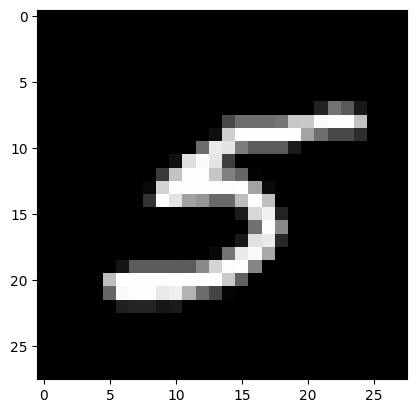

In [49]:
import matplotlib.pyplot as plt

plt.imshow(xs_data[0].reshape(28,28),cmap='gray',vmin=0,vmax=1)

In [50]:
def loss(params, xs):
    bijector = nnx.merge(graphdef, params, state)
    return jnp.mean(-transformed.logpdf(xs, base_dist, bijector))

In [51]:
@jax.jit
def update(params, opt_state, xs):
    loss_val, grads = jax.value_and_grad(loss)(params, xs)
    grads = jax.tree_util.tree_map(lambda x: jnp.nan_to_num(x, 0.), grads)
    updates, opt_state = optimizer.update(grads, opt_state)
    new_params = optax.apply_updates(params, updates)
    return loss_val, new_params, opt_state

In [114]:
import optax

scheduler = optax.cosine_onecycle_schedule(50_000, 5e-4)
optimizer = optax.chain(optax.clip_by_global_norm(10.0), optax.radam(scheduler))


In [53]:
jax.clear_caches()

In [115]:
opt_state = optimizer.init(params)

In [116]:
datagenerator = train_data_generator(batch_size=64)

In [117]:
for i in range(200):
    l = 0
    for _ in range(100):
        xs_batch = next(datagenerator)
        loss_val, params, opt_state = update(params, opt_state,xs_batch)
        l += loss_val
    print(l/100)

(784, 1)
(784, 120) (784, 1)
(784, 1)
(784, 120) (784, 1)
(784, 1)
(784, 120) (784, 1)
(784, 1)
(784, 120) (784, 1)
(784, 1)
(784, 120) (784, 1)
(784, 1)
(784, 120) (784, 1)
-3851.4668
-3855.5217
-3852.119
-3853.2595
-3854.3025
-3855.0317
-3852.5435
-3851.4226
-3855.3127
-3855.3965
-3851.9019
-3852.4158
-3853.7312
-3852.41
-3850.0073
-3853.503
-3855.0527
-3853.0774
-3851.5386
-3852.1196
-3852.17
-3852.683
-3850.9
-3851.4724
-3852.8777
-3851.7483
-3853.4475
-3851.8953
-3853.8606
-3847.6077
-3850.812
-3851.8262
-3853.7935
-3850.342
-3851.698
-3852.188
-3852.0981
-3851.912
-3850.736
-3850.717
-3853.5037
-3850.7236
-3848.4824
-3852.4746
-3850.7478
-3848.949
-3848.498
-3850.493
-3850.5427
-3847.8843
-3850.9258
-3846.2683
-3850.1667
-3847.7656
-3847.1365
-3847.8953
-3847.8538
-3846.2593
-3848.1072
-3850.621
-3842.614
-3844.9639
-3844.3955
-3844.2522
-3848.0603
-3845.324
-3849.4546
-3843.421
-3847.2075
-3844.9524
-3846.988
-3843.7075
-3844.4727
-3851.413
-3846.283
-3846.1006
-3843.8083
-3843.

KeyboardInterrupt: 

In [106]:
# Save params
import pickle

with open('params_spline2.pkl', 'wb') as f:
    pickle.dump(params, f)

# # Load params
# with open('params.pkl', 'rb') as f:
#     params = pickle.load(f)

In [118]:
bijector = nnx.merge(graphdef, params, state)
p = transformed(base_dist, bijector)


In [119]:
samples = p.rvs(jax.random.PRNGKey(0), shape=(16, ))

(784, 1)
(784, 120) (784, 1)
(784, 1)
(784, 120) (784, 1)
(784, 1)
(784, 120) (784, 1)
(784, 1)
(784, 120) (784, 1)
(784, 1)
(784, 120) (784, 1)
(784, 1)
(784, 120) (784, 1)


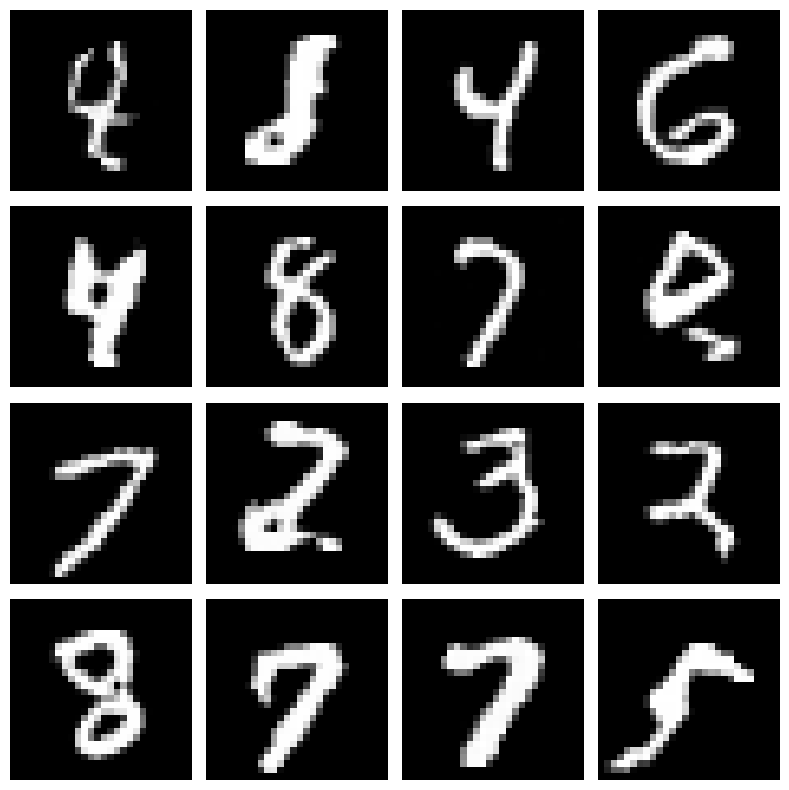

In [120]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(4, 4, figsize=(8, 8))
for i, ax in enumerate(axes.flat):
    ax.imshow(samples[i].reshape(28, 28), cmap='gray')
    ax.axis('off')
plt.tight_layout()
plt.show()

# Eval in bits per dimension

State-of-the art density estimator.

In [121]:
# Compute bits per dimension on the test set

# Get test set using datasets
test_images = dataset['test']['image']
test_images = (test_images.astype('float32') + np.random.rand(*test_images.shape)) / 256.0
test_images = test_images.clip(1e-6, 1-1e-6)
test_images = test_images.reshape(-1, 28*28)

# Compute log likelihoods in batches of 1000
batch_size = 1000
log_probs_list = []
for i in range(0, test_images.shape[0], batch_size):
    batch = test_images[i:i+batch_size]
    batch_log_probs = p.logpdf(batch)
    batch_log_probs = batch_log_probs[np.isfinite(batch_log_probs)]
    log_probs_list.append(batch_log_probs)
log_probs = np.concatenate(log_probs_list)

D = 28*28                       # 784
log_px = log_probs - D*np.log(256.0)     # subtract, not add
bits_per_dim = -log_px / (D*np.log(2.0))

print(bits_per_dim.mean())      # ≈ 1.65  (sensible for MNIST)


(784, 1)
(784, 120) (784, 1)
(784, 1)
(784, 120) (784, 1)
(784, 1)
(784, 120) (784, 1)
(784, 1)
(784, 120) (784, 1)
(784, 1)
(784, 120) (784, 1)
(784, 1)
(784, 120) (784, 1)
0.9309252642445832
